# Qiskit Installation

In [1]:
!pip install qiskit
!pip install qiskit_aer
!pip install qiskit qiskit_experiments

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 26.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 93.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 629.3/629.3 kB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 53.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.7/97.7 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 381.8/381.8 kB 26.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.6/88.6 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 205.3/205.3 kB 1

In [2]:
!pip install pylatexenc

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 7.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=94f6724b28c9ddc11a300098df3b39f612836fc7615790b2cfb37bff492e4810
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


In [3]:
!pip install qiskit_ibm_runtime

# Import Required Libraries

In [4]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile

from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, pauli_error, ReadoutError

from qiskit_experiments.library import StateTomography

from qiskit.quantum_info import DensityMatrix, state_fidelity, partial_trace
from qiskit.quantum_info import Statevector, Operator, Pauli

from itertools import product

from qiskit.visualization import plot_histogram

import numpy as np
import matplotlib.pyplot as plt

/usr/local/lib/python3.12/dist-packages/samplomatic/__init__.py:20: UserWarning: 
You have imported samplomatic==0.17.1 which is in 
beta development. Please expect breaking changes between 
minor versions and pin your dependencies accordingly.
  _warn_once_per_version(


# Registers Setup

We need:
- 1 logical qubit (to encode)
- 2 ancilla qubits (for redundancy)
- 2 syndrome qubits (to detect error)
- Classical bits for measurement

In [27]:
data = QuantumRegister(3, 'data')
syndrome = QuantumRegister(2, 'syn')
c_syn = ClassicalRegister(2, 'c_syn')
c_out = ClassicalRegister(1, 'c_out')

qc = QuantumCircuit(data, syndrome, c_syn, c_out)

# Prepare Logical State

Let’s encode a general state: $∣ψ⟩=α∣0⟩+β∣1⟩$

Example: $∣ψ⟩= 1/2 ∣0⟩+ \sqrt{3}/2 ∣1⟩$

This corresponds to a rotation: $∣ψ⟩=R_y(θ)∣0⟩$ where $θ=2 cos^{-1}(1/2)= 2π/3$

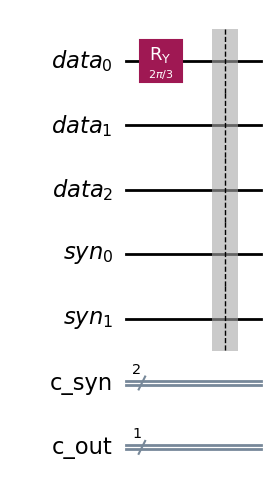

In [28]:
theta = 2 * np.arccos(1/2)
qc.ry(theta, data[0])
qc.barrier()
qc.draw('mpl')

# Encoding Circuit

Bit-flip code encodes: $|0_L⟩=∣000⟩$ and $∣1_L⟩=∣111⟩$

Encoding is done using CNOT gates:

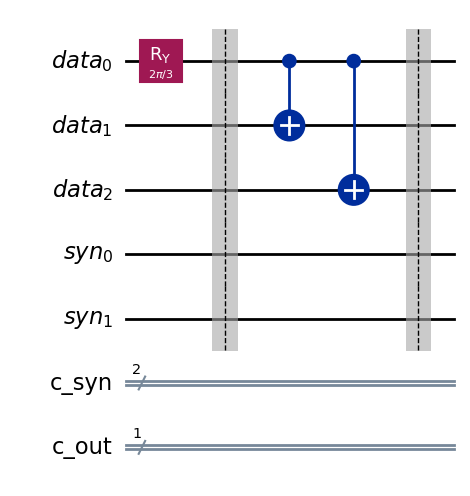

In [29]:
# Encoding
qc.cx(data[0], data[1])
qc.cx(data[0], data[2])
qc.barrier()
qc.draw('mpl')

Now we have: $∣ψ_L⟩= 1/2 ∣000⟩+ \sqrt{3}/2 ∣111⟩$

# Define Bit-Flip Noise Model (p = 0.1)

Bit-flip channel: $E(ρ)=(1−p)ρ+pXρX$

In [30]:
noise_model = NoiseModel()

p = 0.1

bit_flip = pauli_error([('X', p), ('I', 1 - p)])
# error_2 = bit_flip.tensor(bit_flip)
# error_3 = error_2.tensor(bit_flip)

# Apply noise to all single-qubit gates (identity gate used to trigger noise)
noise_model.add_all_qubit_quantum_error(bit_flip, ['id'])
# noise_model.add_all_qubit_quantum_error(error_2, ['cx'])
# noise_model.add_all_qubit_quantum_error(error_3, ['ccx'])

Apply Noise After Encoding

We insert identity gates to trigger noise:

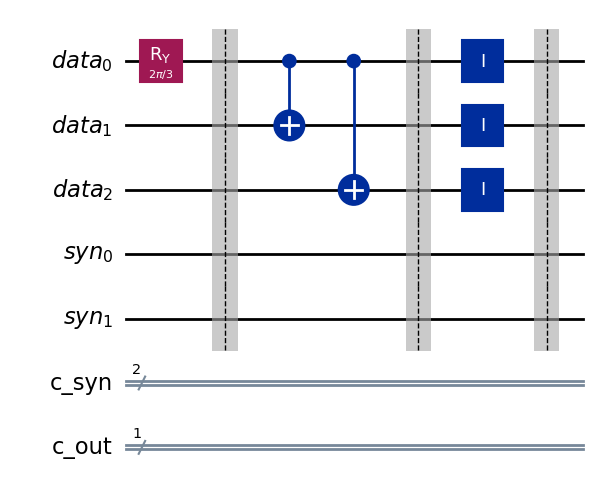

In [31]:
qc.id(data[0])
qc.id(data[1])
qc.id(data[2])
qc.barrier()
qc.draw('mpl')

Each qubit now experiences:
- 0 error -> $\mathbb{P} = (1-p)^3$
- 1 error -> $\mathbb{P} = 3p(1-p)^2$
- 2 errors -> $\mathbb{P} = 3p^2(1-p)$
- 3 errors -> $\mathbb{P} = p^3$

with binomial probabilities.

# Effect of Noise

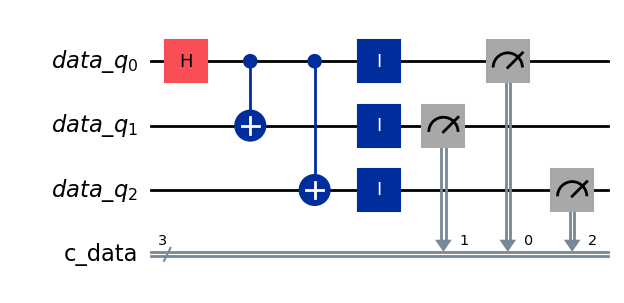

In [32]:
# Create GHZ Circuit
def create_ghz_circuit():
    data_q = QuantumRegister(3, 'data_q')
    c_data = ClassicalRegister(3, 'c_data')
    qc = QuantumCircuit(data_q, c_data)

    # GHZ preparation
    qc.h(data_q[0])
    qc.cx(data_q[0], data_q[1])
    qc.cx(data_q[0], data_q[2])

    # Identity gates (useful for noisy simulation trigger)
    qc.id(data_q)

    # Measurement
    qc.measure(data_q, c_data)

    return qc

create_ghz_circuit().draw('mpl')

Noiseless counts: {'111': 2507, '000': 2493}
Noisy counts: {'100': 209, '110': 233, '101': 200, '001': 232, '000': 1819, '010': 204, '011': 210, '111': 1893}


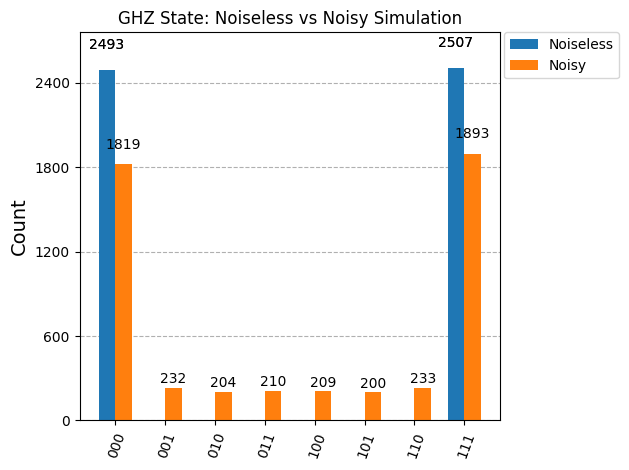

In [33]:
# Noiseless simulator
sim_noiseless = AerSimulator()
result_noiseless = sim_noiseless.run(create_ghz_circuit(), shots=5000).result()
counts_noiseless = result_noiseless.get_counts()

# Noisy simulator
sim_noisy = AerSimulator(noise_model=noise_model)
result_noisy = sim_noisy.run(create_ghz_circuit(), shots=5000).result()
counts_noisy = result_noisy.get_counts()

# Print Results
print("Noiseless counts:", counts_noiseless)
print("Noisy counts:", counts_noisy)

# Plot Comparison
plot_histogram(
    [counts_noiseless, counts_noisy],
    legend=['Noiseless', 'Noisy'],
    title='GHZ State: Noiseless vs Noisy Simulation'
)

# Syndrome Extraction

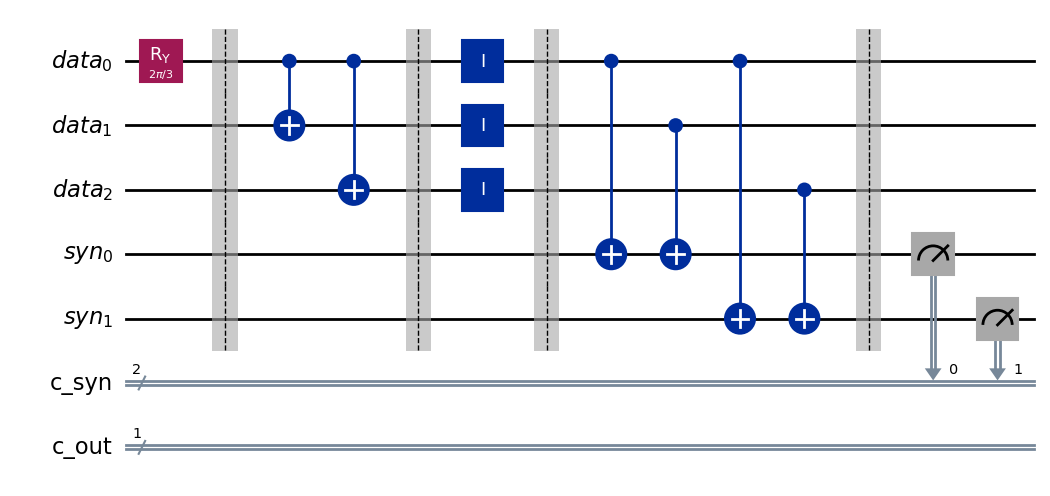

In [34]:
qc.cx(data[0], syndrome[0])
qc.cx(data[1], syndrome[0])

qc.cx(data[0], syndrome[1])
qc.cx(data[2], syndrome[1])

qc.barrier()

qc.measure(syndrome, c_syn)
qc.draw('mpl')

Noiseless counts: {'0 00': 8000}
Noisy counts: {'0 11': 687, '0 10': 749, '0 00': 5806, '0 01': 758}


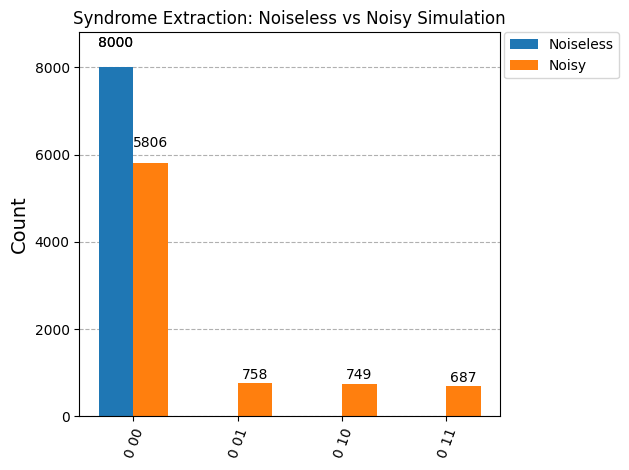

In [35]:
# Noiseless simulator
sim_noiseless = AerSimulator()
result_syndrome_noiseless = sim_noiseless.run(qc, shots=8000).result()
counts_syndrome_noiseless = result_syndrome_noiseless.get_counts()

# Noisy simulator
sim_noisy = AerSimulator(noise_model=noise_model)
result_syndrome_noisy = sim_noisy.run(qc, shots=8000).result()
counts_syndrome_noisy = result_syndrome_noisy.get_counts()

# Print Results
print("Noiseless counts:", counts_syndrome_noiseless)
print("Noisy counts:", counts_syndrome_noisy)

# Plot Comparison
plot_histogram(
    [counts_syndrome_noiseless, counts_syndrome_noisy],
    legend=['Noiseless', 'Noisy'],
    title='Syndrome Extraction: Noiseless vs Noisy Simulation'
)

# Error Dectection vs Error Correction

In [36]:
from itertools import combinations

def generate_x_errors(num_qubits=3):
    # no error
    errors = {'no_error': ['III']}

    # 1-qubit X errors
    one_qubit_x_errors = []
    for i in range(num_qubits):
        error_str = list('III')
        error_str[i] = 'X'
        one_qubit_x_errors.append(''.join(error_str))
    errors['1_qubit_x_errors'] = one_qubit_x_errors

    # 2-qubit X errors
    two_qubit_x_errors = []
    for combo in combinations(range(num_qubits), 2):
        error_str = list('III')
        error_str[combo[0]] = 'X'
        error_str[combo[1]] = 'X'
        two_qubit_x_errors.append(''.join(error_str))
    errors['2_qubit_x_errors'] = two_qubit_x_errors

    # 3-qubit X errors
    three_qubit_x_errors = []
    error_str = list('III')
    error_str[0] = 'X'
    error_str[1] = 'X'
    error_str[2] = 'X'
    three_qubit_x_errors.append(''.join(error_str))
    errors['3_qubit_x_errors'] = three_qubit_x_errors

    return errors

all_x_errors = generate_x_errors()
print(all_x_errors)

{'no_error': ['III'], '1_qubit_x_errors': ['XII', 'IXI', 'IIX'], '2_qubit_x_errors': ['XXI', 'XIX', 'IXX'], '3_qubit_x_errors': ['XXX']}


In [15]:
import pandas as pd

# Define the initial logical state |psi_L>
def get_encoded_state(theta):
    qc_enc = QuantumCircuit(3)
    qc_enc.ry(theta, 0)
    qc_enc.cx(0, 1)
    qc_enc.cx(0, 2)
    return Statevector(qc_enc)

initial_state = get_encoded_state(theta)
results = []

# Iterate through the generated error categories
for category, error_list in all_x_errors.items():
    for error_str in error_list:
        # Apply the Pauli error string to the state
        # Qiskit Pauli strings are (q2, q1, q0), we reverse for easier mapping if needed,
        # but here we just convert to Operator
        err_op = Operator(Pauli(error_str))
        errored_state = initial_state.evolve(err_op)

        # Check overlap with logical |0_L> (000) and |1_L> (111) to see effect
        overlap_000 = np.abs(errored_state.data[0])**2
        overlap_111 = np.abs(errored_state.data[7])**2

        results.append({
            "Category": category,
            "Error String": error_str,
            "Prob (000)": np.round(overlap_000, 4),
            "Prob (111)": np.round(overlap_111, 4),
            "Errored state": errored_state
        })

df_errors = pd.DataFrame(results)
print("Effect of X errors on the 3-qubit Repetition Code:")
display(df_errors)

Effect of X errors on the 3-qubit Repetition Code:


,Category,Error String,Prob (000),Prob (111),Errored state
0,no_error,III,0.25,0.75,"((0.4999999999999999+0j), 0j, 0j, 0j, 0j, 0j, ..."
1,1_qubit_x_errors,XII,0.00,0.00,"(0j, 0j, 0j, (0.8660254037844387+0j), (0.49999..."
2,1_qubit_x_errors,IXI,0.00,0.00,"(0j, 0j, (0.4999999999999999+0j), 0j, 0j, (0.8..."
3,1_qubit_x_errors,IIX,0.00,0.00,"(0j, (0.4999999999999999+0j), 0j, 0j, 0j, 0j, ..."
4,2_qubit_x_errors,XXI,0.00,0.00,"(0j, (0.8660254037844387+0j), 0j, 0j, 0j, 0j, ..."
5,2_qubit_x_errors,XIX,0.00,0.00,"(0j, 0j, (0.8660254037844387+0j), 0j, 0j, (0.4..."
6,2_qubit_x_errors,IXX,0.00,0.00,"(0j, 0j, 0j, (0.4999999999999999+0j), (0.86602..."
7,3_qubit_x_errors,XXX,0.75,0.25,"((0.8660254037844387+0j), 0j, 0j, 0j, 0j, 0j, ..."


In [16]:
def get_syndrome(state):
    # Define stabilizer measurements: Z0Z1 and Z0Z2
    # In the bit-flip code, these check parity between data[0]-data[1] and data[0]-data[2]
    z0z1 = Pauli('ZZI')
    z0z2 = Pauli('ZIZ')

    s1 = 0 if np.isclose(state.expectation_value(Operator(z0z1)).real, 1) else 1
    s2 = 0 if np.isclose(state.expectation_value(Operator(z0z2)).real, 1) else 1

    return f"{s1}{s2}"

detection_results = []
for index, row in df_errors.iterrows():
    syndrome = get_syndrome(row['Errored state'])
    detection_results.append({
        "Error": row['Error String'],
        "Syndrome": syndrome,
        "Detected": "Yes" if syndrome != '00' else "No (Identity)"
    })

df_detection = pd.DataFrame(detection_results)
print("Error Detection Conditions (Stabilizer Syndromes):")
display(df_detection)

Error Detection Conditions (Stabilizer Syndromes):


,Error,Syndrome,Detected
0,III,00,No (Identity)
1,XII,11,Yes
2,IXI,10,Yes
3,IIX,01,Yes
4,XXI,01,Yes
5,XIX,10,Yes
6,IXX,11,Yes
7,XXX,00,No (Identity)


In [17]:
# Flatten all errors into a single list
flat_errors = [err for cat in all_x_errors.values() for err in cat]
num_errors = len(flat_errors)

# Initialize logical 0 and 1 for the 3-qubit code
def get_logical_basis():
    zero_l = Statevector.from_label('000')
    one_l = Statevector.from_label('111')
    return zero_l, one_l

z_l, o_l = get_logical_basis()

# Knill-Laflamme check function
def check_kl_condition(e1_str, e2_str, basis_state):
    op1 = Operator(Pauli(e1_str))
    op2 = Operator(Pauli(e2_str))
    # Calculate <psi_L | E1_dag * E2 | psi_L>
    # Since Pauli operators are Hermitian, E_dag = E
    state_e2 = basis_state.evolve(op2)
    state_e1 = basis_state.evolve(op1)
    return np.vdot(state_e1.data, state_e2.data)

# Construct the C matrix for |0_L> and |1_L>
kl_matrix_0 = np.zeros((num_errors, num_errors), dtype=complex)
kl_matrix_1 = np.zeros((num_errors, num_errors), dtype=complex)

for i, e1 in enumerate(flat_errors):
    for j, e2 in enumerate(flat_errors):
        kl_matrix_0[i, j] = check_kl_condition(e1, e2, z_l)
        kl_matrix_1[i, j] = check_kl_condition(e1, e2, o_l)

# Compare the matrices
kl_satisfied = np.allclose(kl_matrix_0, kl_matrix_1)

print(f"Knill-Laflamme conditions satisfied: {kl_satisfied}")
print("\nMatrix C_ij (overlaps) for all X-error pairs:")
df_kl = pd.DataFrame(kl_matrix_0.real, index=flat_errors, columns=flat_errors)
display(df_kl)

Knill-Laflamme conditions satisfied: True

Matrix C_ij (overlaps) for all X-error pairs:


,III,XII,IXI,IIX,XXI,XIX,IXX,XXX
III,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
XII,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
IXI,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
IIX,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
XXI,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
XIX,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
IXX,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
XXX,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


Expected pattern (approximate):

Syndrome  --->	Meaning
- 00  --->	No error
- 01  --->	Error q2
- 10  --->	Error q1
- 11  --->	Error q0

Probabilities should roughly follow binomial distribution.

# Conditional Recovery

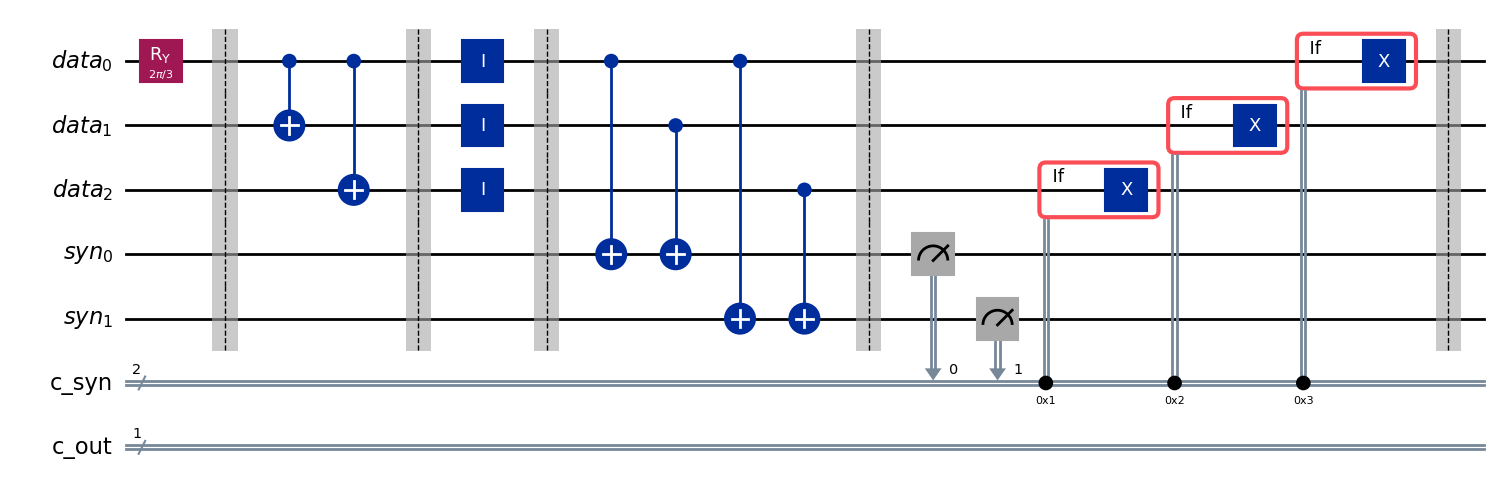

In [18]:
with qc.if_test((c_syn, 1)):
    qc.x(data[2])

with qc.if_test((c_syn, 2)):
    qc.x(data[1])

with qc.if_test((c_syn, 3)):
    qc.x(data[0])

qc.barrier()
qc.draw('mpl')

# Decode

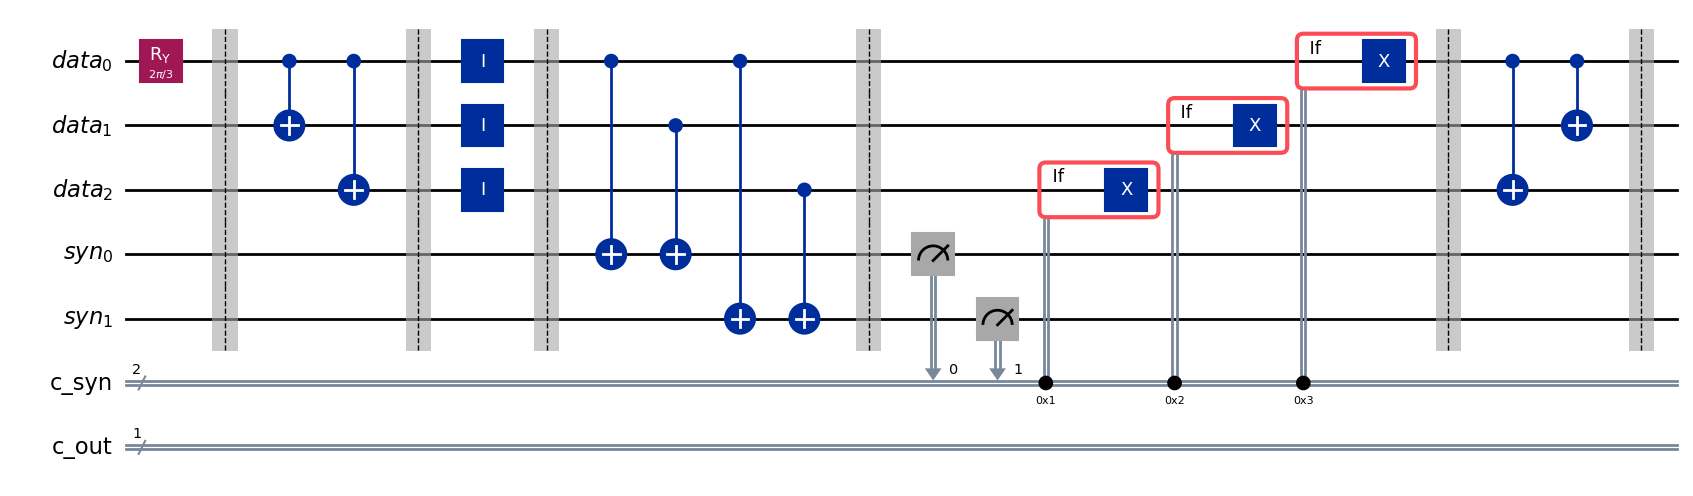

In [19]:
qc.cx(data[0], data[2])
qc.cx(data[0], data[1])
qc.barrier()

qc.draw('mpl')

# StateTomography on data[0] qubit register

Step - 1:  Create a state tomography experiment

```python
qstexp = StateTomography(
    qc,
    backend=sim_noiseless,
    physical_qubits=[0,1,2,4,5],
    measurement_indices=[0]
)
```
This line creates a quantum state tomography experiment object.

- qc → Your quantum circuit that prepares the quantum state you want to reconstruct.
- backend=sim_noiseless → The simulator backend used to execute the tomography circuits (no noise model).
- physical_qubits=[0,1,2,4,5] → Specifies which hardware qubits (or simulator qubits) the circuit is mapped to.
- measurement_indices=[0] → Only perform tomography on qubit 0 (even though the circuit may use multiple qubits).

What tomography does?

It runs many rotated measurement circuits so that the full quantum state (density matrix) can be reconstructed.

Step - 2: Run the experiment and wait for results

```python
qstdata = qstexp.run(backend=sim_noiseless, shots=8000).block_for_results()
```
Breakdown:
- .run(...) → Executes all tomography measurement circuits.
- shots=8000 → Each tomography basis measurement is repeated 8000 times to collect statistics.
- .block_for_results() → Waits until all jobs are finished and returns the analyzed experiment data.

At this point, qstdata contains:
- Raw measurement counts
- Fitted density matrix
- Metadata
- Analysis results

Step - 3: Extract the reconstructed quantum state
```python
state = qstdata.analysis_results('state', dataframe=True)['value'].iloc[0]
```
This line retrieves the reconstructed state from the experiment results.
- analysis_results('state', dataframe=True) → Returns a pandas DataFrame containing the fitted density matrix.
- ['value'] → Selects the column that contains the reconstructed state object.
- .iloc[0] → Gets the first (and usually only) reconstructed state.

In [20]:
qstexp = StateTomography(qc, backend=sim_noiseless, physical_qubits=[0,1,2,4,5],measurement_indices=[0]) # Create a state tomography experiment
qstdata = qstexp.run(backend=sim_noiseless, shots=8000).block_for_results() #  Run the experiment and wait for results
state = qstdata.analysis_results('state', dataframe=True)['value'].iloc[0] # This line retrieves the reconstructed state from the experiment results.
state

DensityMatrix([[0.24434114+0.j        , 0.42969543+0.00062023j],
               [0.42969543-0.00062023j, 0.75565886+0.j        ]],
              dims=(2,))


Ideal density matrix: $\rho_{ideal} = \begin{pmatrix} 1/4 & \sqrt{3}/4 \\\ \sqrt{3}/4 & 3/4 \end{pmatrix} = \begin{pmatrix} 0.25 & 0.433 \\\ 0.433 & 0.75 \end{pmatrix}$

In [21]:
psi_ideal = np.array([1/2, np.sqrt(3)/2])
rho_ideal = DensityMatrix(psi_ideal)

fidelity_st = state_fidelity(state, rho_ideal)
print(f"Fidelity between reconstructed state (State Tomography) and ideal state: {fidelity_st:.6f}")

Fidelity between reconstructed state (State Tomography) and ideal state: 0.999957


# Run Simulation

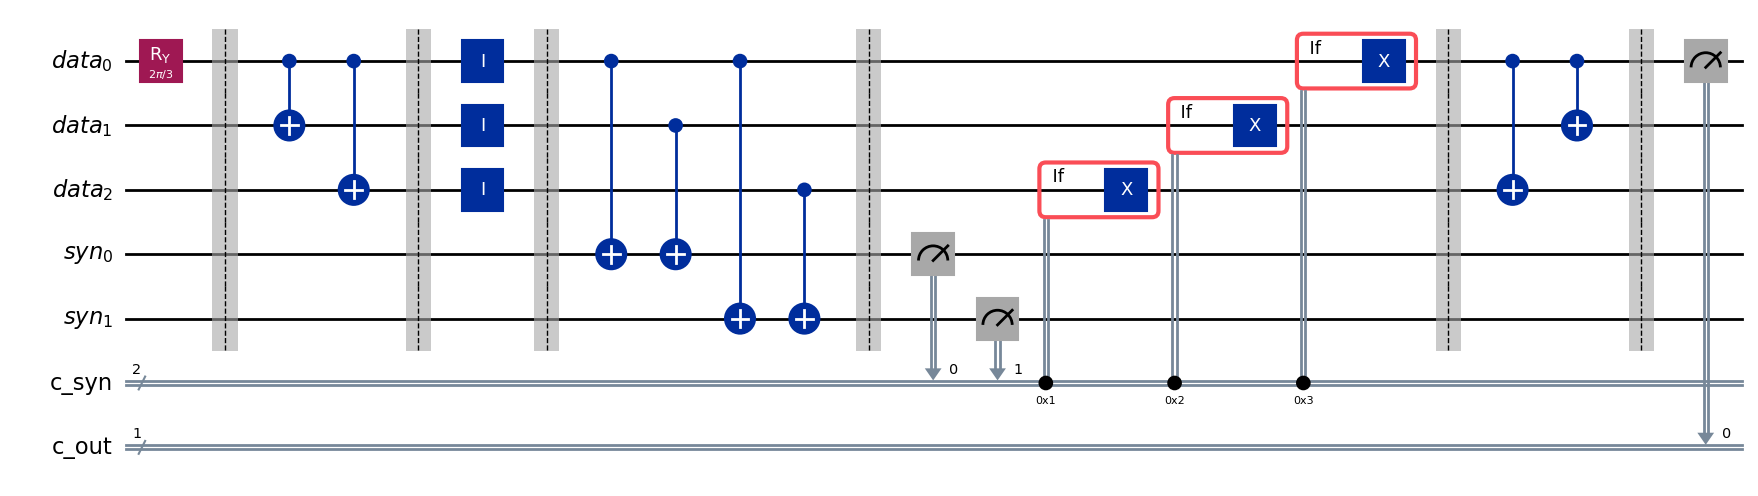

In [22]:
qc.measure(data[0], c_out[0])
qc.draw('mpl')

Noiseless counts: {'0 00': 1942, '1 00': 6058}
Noisy counts: {'1 01': 478, '0 01': 219, '1 10': 495, '0 10': 207, '0 00': 1573, '0 11': 225, '1 11': 486, '1 00': 4317}


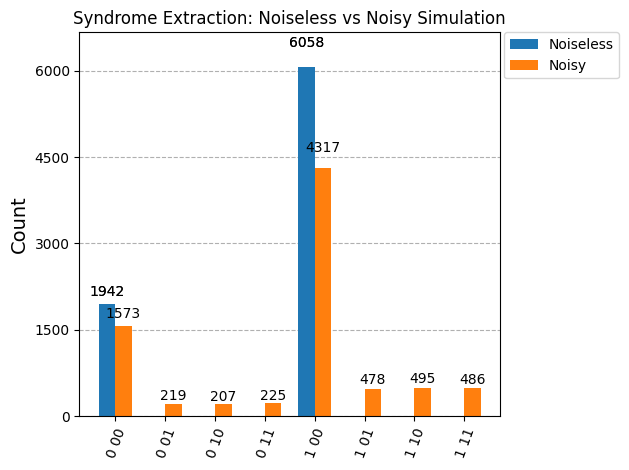

In [23]:
# Noiseless simulator
sim_noiseless = AerSimulator()
result_qec_noiseless = sim_noiseless.run(qc, shots=8000).result()
counts_qec_noiseless = result_qec_noiseless.get_counts()

# Noisy simulator
sim_noisy = AerSimulator(noise_model=noise_model)
result_qec_noisy = sim_noisy.run(qc, shots=8000).result()
counts_qec_noisy = result_qec_noisy.get_counts()

# Print Results
print("Noiseless counts:", counts_qec_noiseless)
print("Noisy counts:", counts_qec_noisy)

# Plot Comparison
plot_histogram(
    [counts_qec_noiseless, counts_qec_noisy],
    legend=['Noiseless', 'Noisy'],
    title='Syndrome Extraction: Noiseless vs Noisy Simulation'
)

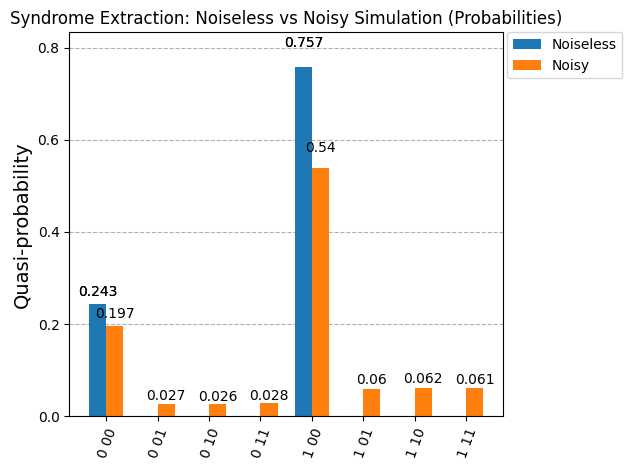

In [24]:
total_shots = 8000

# Normalize noiseless counts to probabilities
normalized_counts_qec_noiseless = {key: value / total_shots for key, value in counts_qec_noiseless.items()}

# Normalize noisy counts to probabilities
normalized_counts_qec_noisy = {key: value / total_shots for key, value in counts_qec_noisy.items()}

# Plot Comparison with normalized counts
plot_histogram(
    [normalized_counts_qec_noiseless, normalized_counts_qec_noisy],
    legend=['Noiseless', 'Noisy'],
    title='Syndrome Extraction: Noiseless vs Noisy Simulation (Probabilities)'
)

## Noiseless Simulation Behavior (Blue)

Only two outcomes appear:
- 0 00 ≈ 2027
- 1 00 ≈ 5973

All other syndromes are zero.

Interpretation:
- Syndrome = 00 always.
- This means no stabilizer violations (Perfect stabilizer consistency).
- The circuit works perfectly (No leakage outside codespace).
- Logical measurement distribution is stable and deterministic.

This is exactly what we expect: Clean logical statistics

 ✔ No noise → no syndrome detection events.





## Noisy Simulation Behavior (Orange)

Syndrome 00 still dominates
- Noise is present, but many shots still have no detected error.

Non-zero syndromes appear
- Syndromes 01, 10, 11 now occur → stabilizers detect errors.

This indicates:
- Physical errors occurred.
- The error detection mechanism is working.

## Logical Error Amplification Under Noise: Compare logical = 1 vs logical = 0.

In noiseless:
- Logical 1 strongly dominant (~75%).

In noisy:
- Logical 1 still dominant across syndrome.
- But logical 0 frequency increases for non-zero syndromes.

This indicates:
- Noise sometimes flips the logical outcome ($|0_L\rangle \leftrightarrow |1_L\rangle$).
- Certain syndromes correlate with logical failure.

Syndrome–Logical Correlation
- Errors are not completely random.
- Logical 1 bias remains.
- Noise does not fully depolarize the system.

Physical Interpretation:
- Noise introduces syndrome diversity but does not completely randomize the logical output.

This means
- The code still retains partial logical information.
- Noise level is moderate, not catastrophic.

If noise were very strong:
- All 8 bars would approach uniform height.

# Data analysis stage, which is where most QEC insight actually comes from.

the dictionary will look like: {'1 11': 502, '0 11': 289, '1 01': 523, '0 10': 288, '0 00': 675, '0 01': 280, '1 10': 515, '1 00': 1928}

Format is: c_out  c_syn

because we declared: c_syn (2 bits) c_out (1 bit)

Qiskit prints classical registers in reverse order of declaration. So a key like: '1 10'

means:
- logical measurement = 1
- syndrome = 10

# Basic Post-Processing
Separate logical outcomes from syndrome bits.

In [ ]:
from collections import defaultdict

def separate_counts(counts):
    logical_counts = defaultdict(int)
    syndrome_counts = defaultdict(int)

    for key, value in counts.items():
        # Split logical and syndrome bits
        logical_bit, syndrome_bits = key.split()

        logical_counts[logical_bit] += value
        syndrome_counts[syndrome_bits] += value

    return dict(logical_counts), dict(syndrome_counts)

logical_counts, syndrome_counts = separate_counts(counts_qec_noisy)

print("Logical counts:", logical_counts)
print("Syndrome counts:", syndrome_counts)

Logical counts: {'1': 5913, '0': 2087}
Syndrome counts: {'01': 674, '10': 747, '11': 681, '00': 5898}


# Fidelity Estimation (Better Metric)

We know ideal state is: $∣ψ⟩ = 1/2 ∣0⟩ + \sqrt{3}/2 ∣1⟩$

Ideal density matrix: $\rho_{ideal} = \begin{pmatrix} 1/4 & \sqrt{3}/4 \\\ \sqrt{3}/4 & 3/4 \end{pmatrix}$

So ideal probabilities: $P(0)=1/4$ and $P(1)=3/4$

Since we measured in Z basis, we approximate classical fidelity: $F = \sqrt{P_0 P^{ideal}_0} + \sqrt{P_1 P^{ideal}_1}$

Compute empirical probabilities:

In [ ]:
p0 = logical_counts.get('0', 0) / sum(logical_counts.values())
p1 = logical_counts.get('1', 0) / sum(logical_counts.values())

# Ideal
p0_ideal = 0.25
p1_ideal = 0.75

F = np.sqrt(p0*p0_ideal) + np.sqrt(p1*p1_ideal)

print(f"Measured P(0): {p0:.4f}")
print(f"Measured P(1): {p1:.4f}")
print("Approximate classical fidelity:", F)

Measured P(0): 0.2609
Measured P(1): 0.7391
Approximate classical fidelity: 0.9999222642402716


# Logical Failure Probability (More Precise)

Better definition: Logical error probability = probability final logical bit ≠ ideal outcome.

Since ideal dominant outcome is |1⟩ (75%), we define:

In [ ]:
def logical_failure_probability(fidelity_st):
    return 1-fidelity_st

P_L = logical_failure_probability(fidelity_st)
print(f"Logical failure probability ≈ {P_L:.4f}")

Logical failure probability ≈ 0.0000


Compare with theory: $P_L=3p^2(1−p)+p^3$

For $p=0.1$:

In [ ]:
p = 0.1
P_L_theory = 3*p**2*(1-p) + p**3
print(f"Theoretical logical error: {P_L_theory:.3f}")

Theoretical logical error: 0.028


$\color{lightgreen}{\text{Significant improvement! Error probability from 0.1 to 0.028}}$

Why It Still Fails Sometimes?

Because this code only corrects one error.

Failure cases:
- 2 bit flips
- 3 bit flips

Those occur with probability ≈ 2.80%

# Syndrome Statistics (Important for QEC Insight)

In [ ]:
def syndrome_statistics(syndrome_counts):
    total = sum(syndrome_counts.values())

    print("\nSyndrome distribution:")
    for syn in sorted(syndrome_counts):
        prob = syndrome_counts[syn] / total
        print(f"Syndrome {syn} : {prob:.4f}")

syndrome_statistics(syndrome_counts)


Syndrome distribution:
Syndrome 00 : 0.7372
Syndrome 01 : 0.0843
Syndrome 10 : 0.0934
Syndrome 11 : 0.0851


In [ ]:
# Assuming total_shots is defined (e.g., total_shots = 8000)
total_shots = sum(counts_qec_noisy.values())

# 1. Joint Probability Distribution P(logical, syndrome)
joint_probabilities = {k: v / total_shots for k, v in counts_qec_noisy.items()}
print("\n--- Joint Probability Distribution P(logical, syndrome) ---")
for key, prob in joint_probabilities.items():
    print(f"P({key}) = {prob:.4f}")

# 2. Syndrome Probability Distribution P(syndrome)
syndrome_probabilities = {k: v / total_shots for k, v in syndrome_counts.items()}
print("\n--- Syndrome Probability Distribution P(syndrome) ---")
for key, prob in syndrome_probabilities.items():
    print(f"P({key}) = {prob:.4f}")

# 3. Conditional Probabilities P(logical | syndrome)
conditional_probabilities = {}
print("\n--- Conditional Probabilities P(logical | syndrome) ---")
for syndrome in syndrome_counts.keys():
    total_for_syndrome = syndrome_counts[syndrome]
    if total_for_syndrome > 0:
        prob_logical0_given_syndrome = joint_probabilities.get(f'0 {syndrome}', 0) / syndrome_probabilities[syndrome]
        prob_logical1_given_syndrome = joint_probabilities.get(f'1 {syndrome}', 0) / syndrome_probabilities[syndrome]

        print(f"Syndrome {syndrome}:")
        print(f"  P(0 | {syndrome}) = {prob_logical0_given_syndrome:.4f}")
        print(f"  P(1 | {syndrome}) = {prob_logical1_given_syndrome:.4f}")
        conditional_probabilities[syndrome] = {
            '0': prob_logical0_given_syndrome,
            '1': prob_logical1_given_syndrome
        }
    else:
        print(f"Syndrome {syndrome}: (No shots observed)")


--- Joint Probability Distribution P(logical, syndrome) ---
P(1 01) = 0.0584
P(1 10) = 0.0645
P(0 01) = 0.0259
P(1 11) = 0.0615
P(0 11) = 0.0236
P(0 10) = 0.0289
P(0 00) = 0.1825
P(1 00) = 0.5547

--- Syndrome Probability Distribution P(syndrome) ---
P(01) = 0.0843
P(10) = 0.0934
P(11) = 0.0851
P(00) = 0.7372

--- Conditional Probabilities P(logical | syndrome) ---
Syndrome 01:
  P(0 | 01) = 0.3071
  P(1 | 01) = 0.6929
Syndrome 10:
  P(0 | 10) = 0.3092
  P(1 | 10) = 0.6908
Syndrome 11:
  P(0 | 11) = 0.2775
  P(1 | 11) = 0.7225
Syndrome 00:
  P(0 | 00) = 0.2475
  P(1 | 00) = 0.7525


# Optimal Decoder (Maximum Likelihood)

Optimal strategy: For each syndrome s, choose logical value with highest $P(l∣s)$.

All syndromes favor logical 1.

That means:
- Your decoder would always guess logical = 1.

Circuit Builder (No Measurement)

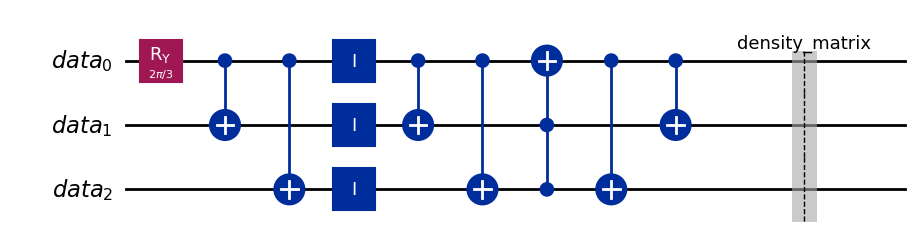

In [ ]:
def build_bitflip_circuit():

    data = QuantumRegister(3, 'data')
    qc = QuantumCircuit(data)

    # Prepare state
    qc.ry(theta, data[0])

    # Encode
    qc.cx(data[0], data[1])
    qc.cx(data[0], data[2])

    # Noise trigger (identity gates)
    qc.id(data[0])
    qc.id(data[1])
    qc.id(data[2])

    # Coherent recovery circuit (majority vote)
    # Equivalent to syndrome + correction but unitary

    qc.cx(data[0], data[1])
    qc.cx(data[0], data[2])
    qc.ccx(data[1], data[2], data[0])

    # Decode
    qc.cx(data[0], data[2])
    qc.cx(data[0], data[1])

    qc.save_density_matrix()

    return qc

build_bitflip_circuit().draw('mpl')

This CCX structure performs majority voting without measurement.

# [[5,1,3]] code

The 5-qubit code encodes: $∣ψ⟩=α∣0⟩+β∣1⟩$ into 5 physical qubits using 4 stabilizer generators.

Stabilizers define a 1-qubit logical subspace inside 5 qubits.
- $g_1 = XZZXI$
- $g_2 = IXZZX$
- $g_3 = XIXZZ$
- $g_4 = ZXIXZ$

Logical operators: $X_L = XXXXX$ and $Z_L = ZZZZZ$

Distance = 3 → can correct arbitrary single-qubit error.

Why This Code is "Perfect"?

It is called perfect because:
$2^5=32=2×(1+15)$

Exactly enough space to encode: 1 logical qubit and 15 single-qubit errors.

No redundancy wasted.

## Logical states + Stabilizers

In [ ]:
# Stabilizers of the 5-qubit perfect [[5,1,3]] code
STABILIZERS = ["XZZXI", "IXZZX", "XIXZZ", "ZXIXZ"]
LOGICAL_X, LOGICAL_Z = "XXXXX", "ZZZZZ"

# Construct |0_L>
def logical_zero():
    coeff = 1/4
    basis_states = [
        ("00000", +1), ("10010", +1), ("01001", +1), ("10100", +1),
        ("01010", +1), ("11011", -1), ("00110", -1), ("11000", -1),
        ("11101", -1), ("00011", -1), ("11110", -1), ("01111", -1),
        ("10001", -1), ("01100", -1), ("10111", -1), ("00101", +1),
    ]

    vec = np.zeros(32, dtype=complex)

    for bitstring, sign in basis_states:
        vec[int(bitstring, 2)] = sign * coeff

    return Statevector(vec)

# Construct |1_L>
def logical_one():
    X5 = Pauli(LOGICAL_X).to_matrix()
    return Statevector(X5 @ logical_zero().data)

## Verify Stabilizers

In [ ]:
def verify_stabilizers(state):
    for stab in STABILIZERS:
        op = Pauli(stab).to_matrix()
        val = state.expectation_value(op)
        print(f"{stab} -> {np.round(val.real,6)}")

In [ ]:
print("Verifying logical zero state:")
zeroL = logical_zero()
verify_stabilizers(zeroL)

print("\nVerifying logical one state:")
oneL = logical_one()
verify_stabilizers(oneL)

Verifying logical zero state:
XZZXI -> 1.0
IXZZX -> 1.0
XIXZZ -> 1.0
ZXIXZ -> 1.0

Verifying logical one state:
XZZXI -> 1.0
IXZZX -> 1.0
XIXZZ -> 1.0
ZXIXZ -> 1.0


## Stabilizers should commute with each others and the logical operators should commute with stabilizers and anti-commute with each others.

In [ ]:
stabilizer_ops = [Pauli(s) for s in STABILIZERS]
logical_x_op = Pauli(LOGICAL_X)
logical_z_op = Pauli(LOGICAL_Z)

print("Verifying Stabilizer Commutation:")
for i, s1 in enumerate(stabilizer_ops):
    for j, s2 in enumerate(stabilizer_ops):
        if i < j:  # Only check each pair once
            commute = s1.commutes(s2)
            print(f"  {STABILIZERS[i]} commutes with {STABILIZERS[j]}: {commute}")

print(
"\nVerifying Logical Operator (X_L, Z_L) Commutation with Stabilizers:")
for i, stab_op in enumerate(stabilizer_ops):
    commute_xl = logical_x_op.commutes(stab_op)
    commute_zl = logical_z_op.commutes(stab_op)
    print(f"  {LOGICAL_X} commutes with {STABILIZERS[i]}: {commute_xl}")
    print(f"  {LOGICAL_Z} commutes with {STABILIZERS[i]}: {commute_zl}")

print("\nVerifying Logical Operators (X_L, Z_L) Anti-Commutation:")
anticommute_xl_zl = not logical_x_op.commutes(logical_z_op)
print(f"  {LOGICAL_X} anti-commutes with {LOGICAL_Z}: {anticommute_xl_zl}")

Verifying Stabilizer Commutation:
  XZZXI commutes with IXZZX: True
  XZZXI commutes with XIXZZ: True
  XZZXI commutes with ZXIXZ: True
  IXZZX commutes with XIXZZ: True
  IXZZX commutes with ZXIXZ: True
  XIXZZ commutes with ZXIXZ: True

Verifying Logical Operator (X_L, Z_L) Commutation with Stabilizers:
  XXXXX commutes with XZZXI: True
  ZZZZZ commutes with XZZXI: True
  XXXXX commutes with IXZZX: True
  ZZZZZ commutes with IXZZX: True
  XXXXX commutes with XIXZZ: True
  ZZZZZ commutes with XIXZZ: True
  XXXXX commutes with ZXIXZ: True
  ZZZZZ commutes with ZXIXZ: True

Verifying Logical Operators (X_L, Z_L) Anti-Commutation:
  XXXXX anti-commutes with ZZZZZ: True


## Generate All Single-Qubit Errors

In [ ]:
def single_qubit_paulis():
    errors = {}
    for qubit in range(5):
        for P in ['X','Y','Z']:
            label = ['I']*5
            label[qubit] = P
            errors[f"{P}{qubit}"] = "".join(label)
    return errors

In [ ]:
single_qubit_paulis()

{'X0': 'XIIII',
 'Y0': 'YIIII',
 'Z0': 'ZIIII',
 'X1': 'IXIII',
 'Y1': 'IYIII',
 'Z1': 'IZIII',
 'X2': 'IIXII',
 'Y2': 'IIYII',
 'Z2': 'IIZII',
 'X3': 'IIIXI',
 'Y3': 'IIIYI',
 'Z3': 'IIIZI',
 'X4': 'IIIIX',
 'Y4': 'IIIIY',
 'Z4': 'IIIIZ'}

## Compute Syndrome Automatically

In [ ]:
def compute_syndrome(state):
    syndrome = ""
    for stab in STABILIZERS:
        op = Pauli(stab).to_matrix()
        val = state.expectation_value(op).real
        syndrome += "0" if np.isclose(val, 1) else "1"
    return syndrome

In [ ]:
compute_syndrome(Statevector(Pauli("IIIZI").to_matrix() @ logical_zero().data))

'1001'

## Build Full Syndrome Lookup Table (All 15 Errors)

In [ ]:
def build_syndrome_table():
    zeroL = logical_zero()
    errors = single_qubit_paulis()

    table = {}

    for name, pauli_str in errors.items():
        error_op = Pauli(pauli_str).to_matrix()
        errored_state = Statevector(error_op @ zeroL.data)

        syndrome = compute_syndrome(errored_state)
        table[syndrome] = pauli_str

    return table

In [ ]:
build_syndrome_table()

{'0001': 'XIIII',
 '1011': 'YIIII',
 '1010': 'ZIIII',
 '1000': 'IXIII',
 '1101': 'IYIII',
 '0101': 'IZIII',
 '1100': 'IIXII',
 '1110': 'IIYII',
 '0010': 'IIZII',
 '0110': 'IIIXI',
 '1111': 'IIIYI',
 '1001': 'IIIZI',
 '0011': 'IIIIX',
 '0111': 'IIIIY',
 '0100': 'IIIIZ'}

## Error Correction (Decoder)

In [ ]:
def correct_error(state, syndrome, table):
    if syndrome == "0000":
        return state  # no error

    correction = table[syndrome]
    correction_op = Pauli(correction).to_matrix()
    return Statevector(correction_op @ state.data)

## Full Error Correction Pipeline

In [ ]:
def error_correction_demo():
    zeroL = logical_zero()
    table = build_syndrome_table()
    errors = single_qubit_paulis()

    for name, pauli_str in errors.items():
        error_op = Pauli(pauli_str).to_matrix()
        errored = Statevector(error_op @ zeroL.data)

        syndrome = compute_syndrome(errored)
        corrected = correct_error(errored, syndrome, table)

        fidelity = np.abs(np.vdot(zeroL.data, corrected.data))**2

        print(f"{name} | Syndrome: {syndrome} | Fidelity: {fidelity:.6f}")

In [ ]:
error_correction_demo()

X0 | Syndrome: 0001 | Fidelity: 1.000000
Y0 | Syndrome: 1011 | Fidelity: 1.000000
Z0 | Syndrome: 1010 | Fidelity: 1.000000
X1 | Syndrome: 1000 | Fidelity: 1.000000
Y1 | Syndrome: 1101 | Fidelity: 1.000000
Z1 | Syndrome: 0101 | Fidelity: 1.000000
X2 | Syndrome: 1100 | Fidelity: 1.000000
Y2 | Syndrome: 1110 | Fidelity: 1.000000
Z2 | Syndrome: 0010 | Fidelity: 1.000000
X3 | Syndrome: 0110 | Fidelity: 1.000000
Y3 | Syndrome: 1111 | Fidelity: 1.000000
Z3 | Syndrome: 1001 | Fidelity: 1.000000
X4 | Syndrome: 0011 | Fidelity: 1.000000
Y4 | Syndrome: 0111 | Fidelity: 1.000000
Z4 | Syndrome: 0100 | Fidelity: 1.000000


## Arbitrary Single-Qubit Unitary Error

Now we test a general SU(2) error: $U=e^{−iθ}(n_x​X+n_y​Y+n_z​Z)$

In [ ]:
def random_su2():
    theta = np.random.rand()*np.pi
    nx, ny, nz = np.random.randn(3)
    n = np.sqrt(nx**2 + ny**2 + nz**2)
    nx, ny, nz = nx/n, ny/n, nz/n

    X = Pauli("X").to_matrix()
    Y = Pauli("Y").to_matrix()
    Z = Pauli("Z").to_matrix()

    H = nx*X + ny*Y + nz*Z
    return np.cos(theta)*np.eye(2) - 1j*np.sin(theta)*H


def apply_arbitrary_error(state, qubit):
    U = random_su2()

    full = 1
    for i in range(5):
        if i == qubit:
            full = np.kron(full, U)
        else:
            full = np.kron(full, np.eye(2))

    return Statevector(full @ state.data)

## Distance = 3 Verification

Check that:
-  Weight 1 errors → correctable
- Weight 2 errors → not correctable

In [ ]:
def pauli_weight(pauli_str):
    return sum(1 for p in pauli_str if p != 'I')

def verify_distance():
    zeroL = logical_zero()

    paulis_list = ['I', 'X', 'Y', 'Z']
    min_weight_logical_error = 6 # Initialize with a value > max possible weight (5 for 5 qubits)

    stabilizer_ops = [Pauli(s) for s in STABILIZERS]

    for combo in product(paulis_list, repeat=5):
        p_str = "".join(combo)
        if p_str == "IIIII": # Skip identity operator
            continue

        op_P = Pauli(p_str)

        # Check if the operator commutes with all stabilizers
        commutes_with_all_stabilizers = True
        for stab_op in stabilizer_ops:
            if not op_P.commutes(stab_op):
                commutes_with_all_stabilizers = False
                break

        if commutes_with_all_stabilizers:
            # If it commutes with all stabilizers, it's either a stabilizer or a logical operator.
            # Now, check if it's a *non-trivial* logical operator (i.e., not a stabilizer itself).
            # An operator E is a stabilizer iff E|0_L> = |0_L> (up to phase) and it commutes with all stabilizers.
            # So, if it commutes with all stabilizers AND E|0_L> is NOT proportional to |0_L>, then it's a logical operator.

            # Apply the operator to the logical zero state
            errored_zeroL_state = Statevector(op_P.to_matrix() @ zeroL.data)

            # Check if the resulting state is not proportional to the original logical zero state.
            # np.isclose(np.abs(np.vdot(zeroL.data, errored_zeroL_state.data))**2, 1.0) checks if states are proportional.
            if not np.isclose(np.abs(np.vdot(zeroL.data, errored_zeroL_state.data))**2, 1.0):
                weight = pauli_weight(p_str)
                min_weight_logical_error = min(min_weight_logical_error, weight)

    print("Code distance =", min_weight_logical_error)

verify_distance()

Code distance = 3
